# 🧭 Positional Embeddings — Where in the Sequence?

Ep07 showed us that *every token has a vector* — a point in a 2048-dimensional space where
similar tokens cluster together. But there's a problem: **a token's embedding says nothing
about where it appears in the sentence.**

Today we solve that with **positional embeddings** — and then we'll actually *create* an
embedding space from scratch.

---

## Setup

We'll reuse the Qwen tokenizer from Ep07 for consistency — same vocabulary, same tokens.
But we'll build our *own* toy embedding space to really see how it works.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoTokenizer
from collections import Counter
import copy
from IPython.display import HTML

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
qwen_tok = AutoTokenizer.from_pretrained("Qwen/Qwen3.6-35B-A3B", trust_remote_code=True)
print(f"Vocabulary size: {qwen_tok.vocab_size:,}")
print(f"EOS token ID: {qwen_tok.eos_token_id}")

Vocabulary size: 248,044
EOS token ID: 248046


---
## Section 1 — The Problem: Position Must Exist

Consider two sentences:

### *"The dog bit the man."*
### *"The man bit the dog."*

The meaning is opposite, but the tokens are identical — just in different order.
If the embedding layer produces the same vector for "dog" at position 2 and position 4,
how can the model possibly tell them apart?

In [3]:
sentence_a = "The dog bit the man."
sentence_b = "The man bit the dog."

ids_a = qwen_tok.encode(sentence_a)
ids_b = qwen_tok.encode(sentence_b)
tokens_a = qwen_tok.convert_ids_to_tokens(ids_a)
tokens_b = qwen_tok.convert_ids_to_tokens(ids_b)

print(f"A: {' '.join(sentence_a.split()):30s}  →  {ids_a}")
print(f"B: {' '.join(sentence_b.split()):30s}  →  {ids_b}")
print()
# Show tokens side by side
print(f"{'Pos':>4} | {'Token A':>12} | {'ID A':>6} | {'Token B':>12} | {'ID B':>6}")
print("-" * 52)
for i, (ta, tb) in enumerate(zip(tokens_a, tokens_b)):
    display_a = str(ta).replace('Ġ', '␣')
    display_b = str(tb).replace('Ġ', '␣')
    print(f"{i:>4} | {display_a:>12} | {ids_a[i]:>6} | {display_b:>12} | {ids_b[i]:>6}")

A: The dog bit the man.            →  [760, 5388, 2612, 279, 855, 13]
B: The man bit the dog.            →  [760, 855, 2612, 279, 5388, 13]

 Pos |      Token A |   ID A |      Token B |   ID B
----------------------------------------------------
   0 |          The |    760 |          The |    760
   1 |         ␣dog |   5388 |         ␣man |    855
   2 |         ␣bit |   2612 |         ␣bit |   2612
   3 |         ␣the |    279 |         ␣the |    279
   4 |         ␣man |    855 |         ␣dog |   5388
   5 |            . |     13 |            . |     13


Same multiset of token IDs, different order. The embedding layer alone is **position-agnostic** —
it will produce identical vectors for "dog" in both sentences.

The model needs **position information** injected somewhere. That's where positional embeddings come in.

---
## Section 2 — Learned Absolute Positional Embeddings: Region + Slant

The original "Attention Is All You Need" Transformer used **learned absolute positional embeddings**:
a table of shape `(max_seq_len × d_model)` that gets *added* to the token embedding vectors.



### The Metaphor

Think of the token embedding space as a map of concepts:

- **Every token lives in a region or direction** of the 2048-D space — "dog" has its neighborhood,
  "city" has its neighborhood, digits cluster together.
- **The positional embedding adds a *slant*** to that vector. The same token at position 0
  gets pushed one way; at position 10, it's pushed another way — but it stays recognizably
  in the "dog" region.
- It's like saying "dog, but at the start of the sentence" vs "dog, but near the end."

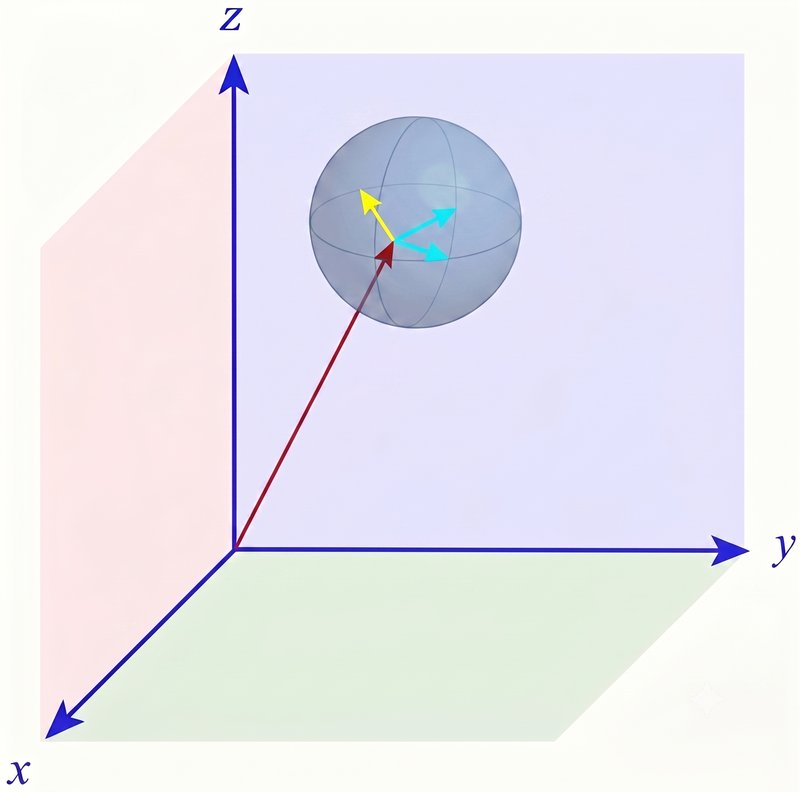

The result: the Transformer sees a vector that encodes *both* what the token is *and* where it sits.

### 2.1 — But Qwen Doesn't Do It This Way

The absolute positional embeddings we just described are the **original Transformer approach** (2017) —
simple, intuitive, easy to train. Many models still use them.

**Qwen**, however, handles position differently. Instead of adding a position vector to the token
embedding, Qwen encodes position **inside the attention mechanism** using a technique called
**Rotary Position Embedding (RoPE)**. The raw embedding vectors coming out of the lookup table
are position-agnostic — position only enters the picture when tokens *interact* with each other
in the transformer blocks.

We'll cover RoPE properly when we get to attention. For now, the key takeaway is:

> However position is encoded, the problem is the same — the model must distinguish
> `"dog"` at position 2 from `"dog"` at position 4. What we build next (a learned
> position table added to embeddings) is one solution; RoPE is another, more elegant one.

Let's continue with the absolute approach — it's the foundation everything else builds on.

---
## Closing the Tokenization Deep-Dive

Over the last two episodes, we've built a complete picture of the **input pipeline**:

```
Text → Token IDs → Embedding Vectors → [Position is handled next]
```

| Ep07 | Ep08 |
|------|------|
| BPE tokenization: how text becomes token IDs | The position problem: same tokens, different positions |
| The embedding matrix: how IDs become vectors | The region + slant metaphor for positional embeddings |
| PCA/t-SNE of Qwen's actual 2048-D embedding space | Qwen handles position inside the attention mechanism, not at the embedding layer |

**The key insight:** The embedding layer gives us positioned concepts. "Dog" has a home region;
its position within the sequence gives that vector a slant within that region.
In Qwen, this position encoding happens later, inside the transformer block.

**Next up:** What's inside that transformer block? We'll start with the attention mechanism —
where tokens finally get to *talk* to each other, and where Qwen's actual position encoding lives.